In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/crowdedness-at-the-campus-gym/data.csv


In [2]:
df=pd.read_csv("/kaggle/input/crowdedness-at-the-campus-gym/data.csv")

## Importing Necessary Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Exploratory Data Analysis

In [4]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [6]:
df.isnull().sum()

number_people           0
date                    0
timestamp               0
day_of_week             0
is_weekend              0
is_holiday              0
temperature             0
is_start_of_semester    0
is_during_semester      0
month                   0
hour                    0
dtype: int64

## Dropping Unneccssary Column

In [7]:
# Drop unnecessary columns
df.drop(columns=["date", "timestamp"], inplace=True)

## Define features and target variable

In [8]:
# Define features and target
X = df.drop(columns=["number_people"])  # Target: 'number_people'
y = df["number_people"]

## Identify categorical and numerical columns

In [9]:
# All are numerical

## train test Split

In [10]:
# Create train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling Features

In [11]:
# Feature Scaling (SVM needs scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM

## Train Model

In [12]:
svm_model = SVR(kernel="rbf")
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

## Evaluate Model

In [13]:
# Evaluate SVM model
mse_svm = mean_squared_error(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print(f"\n🔹 Support Vector Machine (SVM) Results:")
print(f"MSE: {mse_svm:.2f}, MAE: {mae_svm:.2f}, R² Score: {r2_svm:.2f}")


🔹 Support Vector Machine (SVM) Results:
MSE: 194.04, MAE: 10.07, R² Score: 0.62


## Visualization

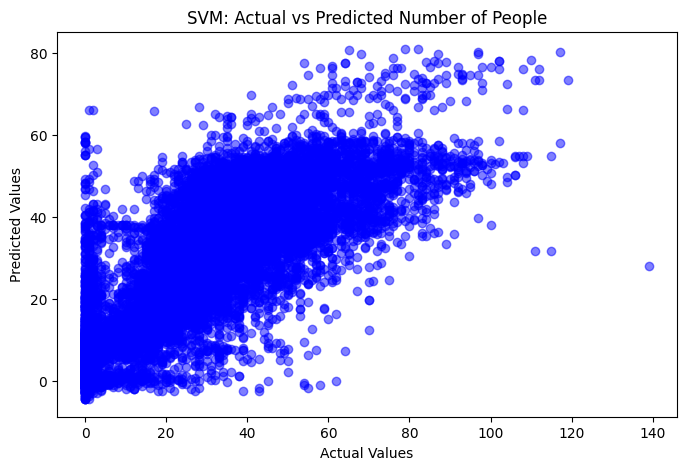

In [14]:

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_svm, alpha=0.5, color="blue")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("SVM: Actual vs Predicted Number of People")
plt.show()

# Decision Tree Regressor

## TrainModel

In [15]:
# Train Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


## EvaluateModel

In [16]:

# Evaluate Decision Tree model
mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"\n🔹 Decision Tree Regression Results:")
print(f"MSE: {mse_dt:.2f}, MAE: {mae_dt:.2f}, R² Score: {r2_dt:.2f}")


🔹 Decision Tree Regression Results:
MSE: 39.95, MAE: 4.25, R² Score: 0.92


## Visualizations

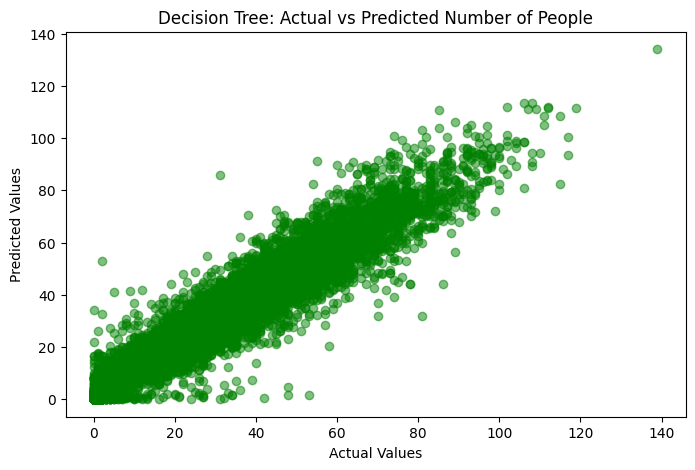

In [17]:
#Plot Predictions
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color="green")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted Number of People")
plt.show()

# Random Forest Regressor

## Training Model

In [18]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


## Evaluating Model

In [19]:

# Evaluate Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n🔹 Random Forest Regression Results:")
print(f"MSE: {mse_rf:.2f}, MAE: {mae_rf:.2f}, R² Score: {r2_rf:.2f}")



🔹 Random Forest Regression Results:
MSE: 38.92, MAE: 4.24, R² Score: 0.92


## Visualizing Prediction

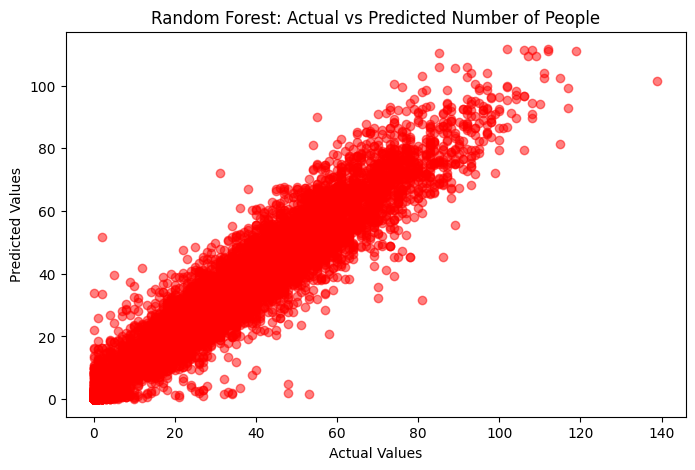

In [20]:

# Plot Predictions
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color="red")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted Number of People")
plt.show()


#  Model Performance Comparison


 Model Performance Comparison:

           Model         MSE        MAE  R² Score
0            SVM  194.036384  10.068448  0.624577
1  Decision Tree   39.952705   4.250642  0.922699
2  Random Forest   38.920279   4.240029  0.924697


<Figure size 1000x500 with 0 Axes>

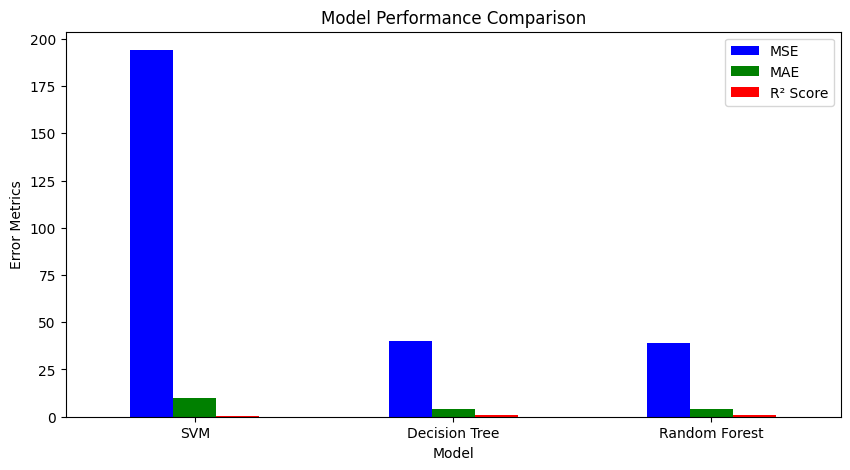

In [21]:
# Store results in a DataFrame
results_df = pd.DataFrame({
    "Model": ["SVM", "Decision Tree", "Random Forest"],
    "MSE": [mse_svm, mse_dt, mse_rf],
    "MAE": [mae_svm, mae_dt, mae_rf],
    "R² Score": [r2_svm, r2_dt, r2_rf]
})

# Print comparison table
print("\n Model Performance Comparison:\n")
print(results_df)

# Plot performance
plt.figure(figsize=(10, 5))
results_df.set_index("Model").plot(kind="bar", figsize=(10, 5), title="Model Performance Comparison", color=["blue", "green", "red"])
plt.ylabel("Error Metrics")
plt.xticks(rotation=0)
plt.show()
